In [2]:
# -*- coding: utf-8 -*-
"""robot_repositor_01.ipynb

Automatically generated by Colab.


# =====================================================================
# Algoritmo de Evaluación de Política
#
# =====================================================================
# _Aprendizaje por Refuerzo I
# _Maestria en Inteligencia Artificial
# _UBA
# _2025
# =====================================================================
"""

import matplotlib.pyplot as plt

"""

Robot repositor (pseudocodigo)

=====================================================================
Entrada: π (la política a ser evaluada)
Inicializar un umbral θ > 0 (determina la precisión de la estimación)
Inicializar V(s) ← 0 para todo estado s

Repetir:
    Δ ← 0
    Para cada estado s en S:
        v ← V(s)
        V(s) ← Σ π(a | s) Σ p(s', r | s, a) [r + γ V(s')]
        Δ ← max(Δ, |v - V(s)|)
hasta que Δ < θ
=====================================================================

"""

# estados y acciones
estados = ["alto", "medio", "bajo"]
acciones = ["reponer", "no reponer"]

# politica (π)
politica = {
    "alto": {"reponer": 0.0, "no reponer": 1.0},
    "medio": {"reponer": 0.4, "no reponer": 0.6},
    "bajo": {"reponer": 0.8, "no reponer": 0.2},
}

# diccionario de recompensas
recompensas = {
    ("alto", "no reponer", "alto"): 8,  # permanecer alto
    ("alto", "no reponer", "medio"): 5,  # bajar a medio
    ("medio", "reponer", "alto"): 5,  # subir a alto
    ("medio", "reponer", "medio"): 3,  # permanecer medio
    ("medio", "no reponer", "bajo"): 0,  # bajar a bajo
    ("medio", "no reponer", "medio"): 3,  # permanecer medio
    ("bajo", "reponer", "medio"): 5,  # subir a medio
    ("bajo", "reponer", "bajo"): 2,  # permanecer en bajo
    ("bajo", "no reponer", "bajo"): 2,  # permanecer en bajo
}


# dinamica del entorno (p(s' | s, a))
def probabilidad_transicion(estado, accion, nuevo_estado):
    if estado == "alto":
        if accion == "no reponer":
            if nuevo_estado == "alto":
                return 0.6  # permanecer alto
            elif nuevo_estado == "medio":
                return 0.4  # bajar a medio
            else:
                return 0
        else:
            return 0  # no deberia haber reponer en estado alto

    elif estado == "medio":
        if accion == "reponer":
            if nuevo_estado == "alto":
                return 0.7  # subir a alto
            elif nuevo_estado == "medio":
                return 0.3  # permanecer medio
            else:
                return 0
        elif accion == "no reponer":
            if nuevo_estado == "bajo":
                return 0.6  # bajar a bajo
            elif nuevo_estado == "medio":
                return 0.4  # permanecer medio
            else:
                return 0

    elif estado == "bajo":
        if accion == "reponer":
            if nuevo_estado == "medio":
                return 0.9  # subir a medio
            elif nuevo_estado == "bajo":
                return 0.1  # permanecer en bajo
            else:
                return 0
        elif accion == "no reponer":
            if nuevo_estado == "bajo":
                return 1.0  # siempre permanece bajo
            else:
                return 0

    return 0  # en caso de que algo no coincida


# factor de descuento
gamma = 0.9

# inicializacion de valores de los estados
valores_estados = {}
for estado in estados:
    valores_estados[estado] = 0

threshold = 0.00001
delta = float("inf")


historial = {}  # para poder hacer un grafico cartesiano de la evolucion de v(s)
for estado in estados:
    historial[estado] = []

iteration = 0  # inicializ. del contador de iteraciones

while delta > threshold:
    delta = 0
    iteration = iteration + 1  #  contador de iteraciones
    for estado in estados:
        valor_viejo = valores_estados[estado]
        valor_nuevo = 0

        for accion in acciones:
            v = 0
            for nuevo_estado in estados:
                # aqui se obtiene la recompensa del diccionario
                recompensa = recompensas.get(
                    (estado, accion, nuevo_estado), 0
                )  # 0 es la recompensa por defecto

                probabilidad = probabilidad_transicion(estado, accion, nuevo_estado)
                v = v + probabilidad * (
                    recompensa + gamma * valores_estados[nuevo_estado]
                )

            valor_nuevo = valor_nuevo + politica[estado][accion] * v

        valores_estados[estado] = valor_nuevo
        delta = max(delta, abs(valor_nuevo - valor_viejo))
        historial[estado].append(valor_nuevo)

    print(f"Valores en la iteración {iteration}: {valores_estados}")

#  resultados finales
print("Valores de los estados:")
for estado, valor in valores_estados.items():
    print(f"{estado}: {valor:.4f}")

Valores en la iteración 1: {'alto': 6.8, 'medio': 4.1936, 'bajo': 6.877452800000001}
Valores en la iteración 2: {'alto': 11.981696, 'medio': 9.086408499200001, 'bajo': 11.781110813081602}
Valores en la iteración 3: {'alto': 16.541222899712, 'medio': 13.409464427906663, 'bajo': 15.818172874180082}
Valores en la iteración 4: {'alto': 20.559667559890876, 'medio': 17.130790710968608, 'bajo': 19.246931945001037}
Valores en la iteración 5: {'alto': 24.06930513828977, 'medio': 20.331847035383188, 'bajo': 22.185263729068566}
Valores en la iteración 6: {'alto': 27.116889707414423, 'medio': 23.0890000939508, 'bajo': 24.712358520605402}
Valores en la iteración 7: {'alto': 29.75516047582608, 'medio': 25.46594063102438, 'bajo': 26.889443876096365}
Valores en la iteración 8: {'alto': 32.03552528411486, 'medio': 27.516096951904068, 'bajo': 28.766570681610126}
Valores en la iteración 9: {'alto': 34.00497855610749, 'medio': 29.284838909397685, 'bajo': 30.38575142505546}
Valores en la iteración 10: {'al

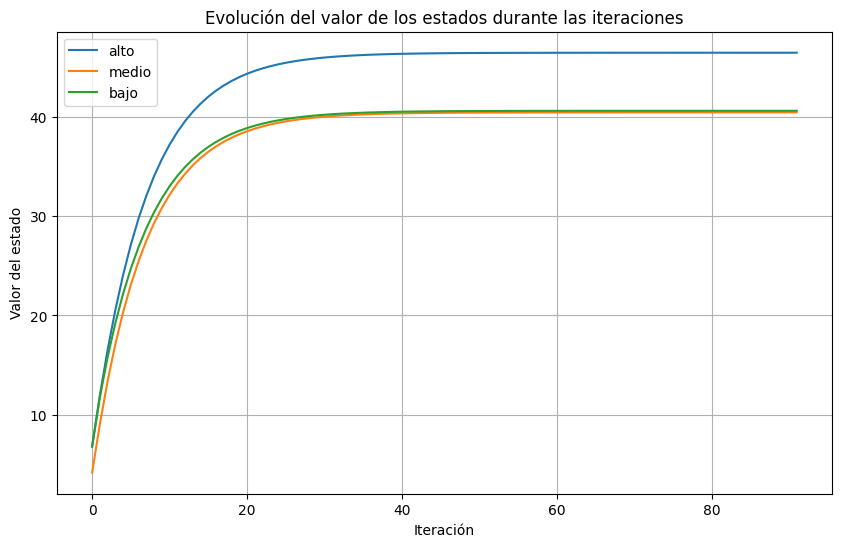

In [3]:
# grafico
plt.figure(figsize=(10, 6))
for estado, valores in historial.items():
    plt.plot(valores, label=estado)

plt.xlabel("Iteración")
plt.ylabel("Valor del estado")
plt.title("Evolución del valor de los estados durante las iteraciones")
plt.legend()
plt.grid(True)
plt.show()